## Choose file 
1: 21 points
<br>
2: 101 points

System after DMD:
 
Max Imaginary Part: 3995.0060596603944
Max Real Part: 825.7286824495104
Total number of eigenvalues: 101
Eigenvalues inside unit circle: 89
Eigenvalues outside the unit circle: 12
System is unstable


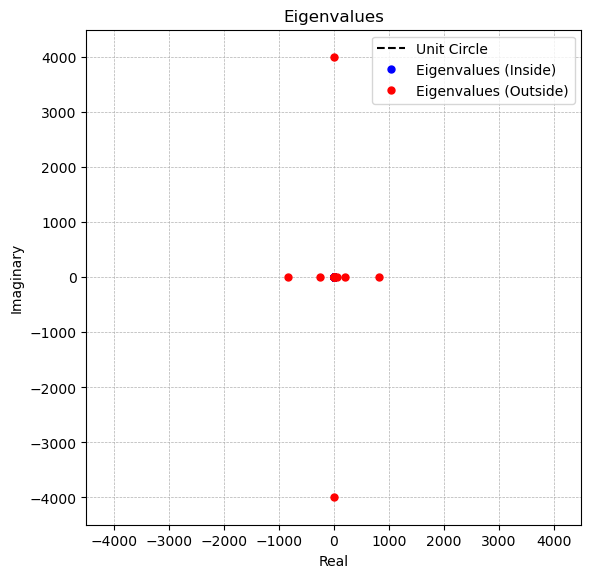

System after DMD with regularization:
 
Lambda: 0.1
Max Imaginary Part: 0.24147370176461894
Max Real Part: 0.944952762136591
Total number of eigenvalues: 101
Eigenvalues inside unit circle: 101
No Eigenvalues outside unit circle
System is stable


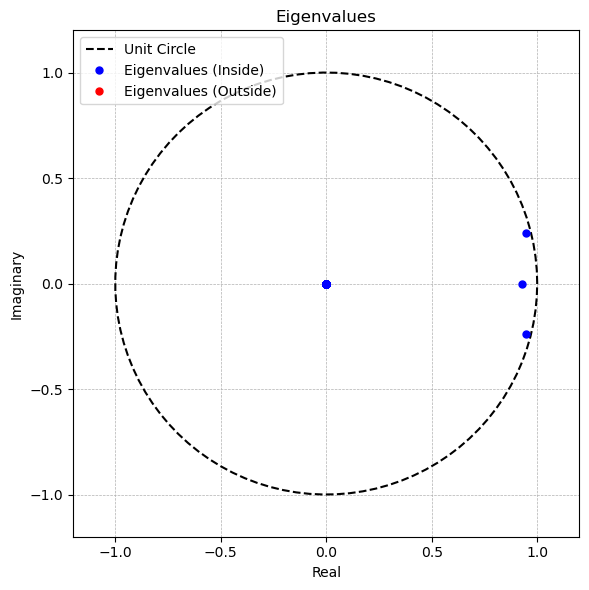

Performance of Kalman Filter: 
 
Total number of states: 101
Number of observable states: 51
Epsilon: 1
Plot Index (time step): 500


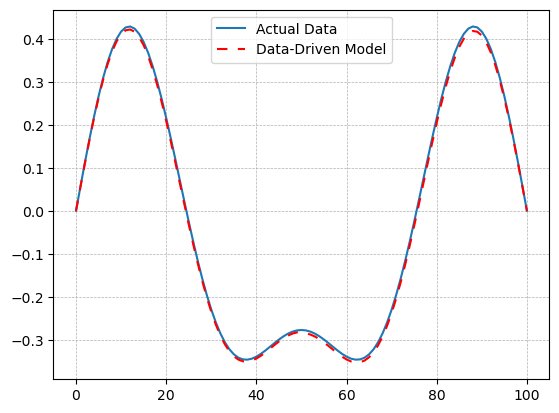

In [21]:
dmd_ekf()

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##################################################################################################################
file_index = 3
##################################################################################################################

def read_data(file_index):
    data = pd.read_csv(filenames[file_index], sep = ",")
    data = data.to_numpy()*10**4
    data = data[10000:,]
    return data

##################################################################################################################
##################################################################################################################

filenames = ['Null','21_points.csv', '101_points.csv', 'm_10_L_2.csv']
data = read_data(file_index)   
dmd_data = data.T
n_states = data.shape[1] #Number of states in the system

##################################################################################################################

n_observed = 51 #Number of measurable states starting from X_1 to X_n_observed

##################################################################################################################

n_steps = 1000 #Number of time steps under consideration
start = 1000 #Starting point of data, to avoid transience if applicable
q = 0.001 #Process Noise
r = 0.01 #Measurement noise
p = 1000 #Initial Covariance
epsilon = 1 #Regularization for Kalman Filter
lambda_reg = 0.1 #Regularization for state-transition
plt_index = 500 #Plot index for Kalman Filter
##################################################################################################################

order = 50 #Lag

##################################################################################################################
start = 1000


##################################################################################################################
##################################################################################################################

def dmd_ekf():
    if n_states < n_observed:
        raise ValueError('Observable states are more than total number of states')
    A_dmd, X_prime, X = A_from_DMD()
    print('System after DMD:')
    print(' ')
    plot_eig(A_dmd)
    print('System after DMD with regularization:')
    print(' ')
    print('Lambda: ' + str(lambda_reg))
    A_reg = state_transition(X_prime, X, lambda_reg)
    plot_eig(A_reg)
    print('Performance of Kalman Filter: ')
    print(' ')
    print('Total number of states: ' + str(n_states))
    print('Number of observable states: ' + str(n_observed))
    print('Epsilon: ' + str(epsilon))
    print('Plot Index (time step): ' + str(plt_index))
    kalman_filter(dmd_data, n_states, n_observed, n_steps, A_reg, epsilon, plt_index)
    
##################################################################################################################
##################################################################################################################

def preview_dmd():
    new_test = start + 1000
    newX = dmd_data[:,new_test - order:new_test]
    newX_prime = np.dot(A_dmd,newX)
    ## Testing
    X_dmd = newX_prime[:,order - 1]
    act_X =dmd_data[:,new_test]
    fig_dmd, ax_dmd = plt.subplots(nrows = 1, ncols = 1)
    ax_dmd.grid(True, linestyle = '--', linewidth = 0.5)
    ax_dmd.plot(np.arange(n_states), act_X, label = 'Actual Data')
    ax_dmd.plot(np.arange(n_states),X_dmd, label = 'Data-Driven Model', linestyle = 'dashed', color = 'r', dashes = (5,5))
    ax_dmd.legend()
    
##################################################################################################################
##################################################################################################################

def A_from_DMD():
    X = dmd_data[:,start:start + order]
    X_prime = dmd_data[:,start + 1:start + order + 1]
    X_pinv = np.linalg.pinv(X)
    A_dmd = np.dot(X_prime,X_pinv)
    return A_dmd, X_prime, X

##################################################################################################################
##################################################################################################################

def plot_eig(A):
    A_eig, _ = np.linalg.eig(A)
    A_eig = np.array(A_eig)
    
    imag_max = np.max(np.abs(np.imag(A_eig)))
    print("Max Imaginary Part: " + str(imag_max))
    
    real_max = np.max(np.abs(np.real(A_eig)))
    print("Max Real Part: " + str(real_max))
    
    fig, ax = plt.subplots(figsize = (6,6))

    theta = np.linspace(0, 2*np.pi, 100)
    x = np.cos(theta)
    y = np.sin(theta)
    ax.plot(x, y, 'k--', linewidth = 1.5, label = 'Unit Circle')
    inside_eig = A_eig[np.abs(A_eig) <= 1]
    outside_eig = A_eig[np.abs(A_eig) > 1]
    
    print("Total number of eigenvalues: " + str(A_eig.shape[0]))
    
    print("Eigenvalues inside unit circle: " + str(inside_eig.shape[0]))
    
    if not outside_eig.size > 0:
        print("No Eigenvalues outside unit circle")
        print("System is stable")
        
    else:
        print("Eigenvalues outside the unit circle: " + str(outside_eig.shape[0]))
        print("System is unstable")
    
    marker_size = 5
    ax.plot(np.real(inside_eig), np.imag(inside_eig), 'bo', markersize= marker_size, label='Eigenvalues (Inside)')
    ax.plot(np.real(outside_eig), np.imag(outside_eig), 'ro', markersize= marker_size, label='Eigenvalues (Outside)')
    
    ax.set_aspect('equal')

    limit = np.max([[imag_max], [real_max]], initial = 1.2)
    if not limit == 1.2:
        limit = limit + 500
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)

    ax.grid(True, linestyle = '--', linewidth = 0.5)

    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    ax.set_title('Eigenvalues')

    ax.legend()
    plt.tight_layout()
    plt.show()
    
##################################################################################################################
##################################################################################################################

def state_transition(X, Y, lambda_reg):
    
    X_reg = X @ X.T + lambda_reg*np.eye(X.shape[0])
    X_pinv_reg = np.linalg.pinv(X_reg) @ X
    A_reg = Y @ X_pinv_reg.T
    return A_reg

##################################################################################################################
##################################################################################################################

def kalman_filter(dmd_data, n_states, n_observed, n_steps, A_reg, epsilon, plt_index = 750):
    Q = np.eye(n_states)*q
    R = np.eye(n_observed)*r 
    P = np.eye(n_states)*p
    w = np.random.multivariate_normal(np.zeros(n_states), Q, 1).T
    v = np.random.multivariate_normal(np.zeros(n_observed), R, 1).T

    H = np.zeros((n_observed, n_states))
    for i in range(n_observed):
        H[i,i] = 1

    x_hat = dmd_data[:,start - 1]
    z = dmd_data[:n_observed,start:start + n_steps]
    A = A_reg
    estimated_states = np.zeros((n_states,n_steps))
    for k in range(n_steps):
        x_hat_pred = np.dot(A_reg,x_hat)
        P_pred = np.dot(np.dot(A,P),A.T) + Q + np.eye(n_states)*epsilon
        if np.trace(P_pred) > 1e10:
            print(k)
            P_pred = np.eye(n_states) * p
        y = z[:,k] - np.dot(H,x_hat_pred)
        S = np.dot(np.dot(H,P_pred),H.T) + R + np.eye(n_observed)*epsilon
        det_S = np.linalg.det(S)
        #if det_S < 1e-6:
            #print(k)
            #print('Near Singular Matrix detected')
            #raise ValueError('Near Singular Matrix detected')
        K = np.dot(np.dot(P_pred,H.T),np.linalg.pinv(S + np.eye(S.shape[0])*epsilon))
        x_hat = x_hat_pred + np.dot(K,y)
        P = np.eye(n_states) - np.dot(np.dot(K,H),P_pred)
        estimated_states[:,k] = x_hat

    fig_kf, ax_kf = plt.subplots(nrows = 1, ncols = 1)
    ax_kf.grid(True, linestyle = '--', linewidth = 0.5)
    ax_kf.plot(np.arange(n_states), dmd_data[:,start + plt_index], label = 'Actual Data')
    ax_kf.plot(np.arange(n_states),estimated_states[:,plt_index], label = 'Data-Driven Model', linestyle = 'dashed', color = 'r', dashes = (5,5))
    ax_kf.legend()

In [ ]:
def dmd_ekf():
    if n_states < n_observed:
        raise ValueError('Observable states are more than total number of states')
    A_dmd, X_prime, X = A_from_DMD()
    print('System after DMD:')
    print(' ')
    plot_eig(A_dmd)
    print('System after DMD with regularization:')
    print(' ')
    print('Lambda: ' + str(lambda_reg))
    A_reg = state_transition(X_prime, X, lambda_reg)
    plot_eig(A_reg)
    print('Performance of Kalman Filter: ')
    print(' ')
    print('Total number of states: ' + str(n_states))
    print('Number of observable states: ' + str(n_observed))
    print('Epsilon: ' + str(epsilon))
    print('Plot Index (time step): ' + str(plt_index))
    kalman_filter(dmd_data, n_states, n_observed, n_steps, A_reg, epsilon, plt_index)

In [ ]:
def preview_dmd():
    new_test = start + 1000
    newX = dmd_data[:,new_test - order:new_test]
    newX_prime = np.dot(A_dmd,newX)
    ## Testing
    X_dmd = newX_prime[:,order - 1]
    act_X =dmd_data[:,new_test]
    fig_dmd, ax_dmd = plt.subplots(nrows = 1, ncols = 1)
    ax_dmd.grid(True, linestyle = '--', linewidth = 0.5)
    ax_dmd.plot(np.arange(n_states), act_X, label = 'Actual Data')
    ax_dmd.plot(np.arange(n_states),X_dmd, label = 'Data-Driven Model', linestyle = 'dashed', color = 'r', dashes = (5,5))
    ax_dmd.legend()

In [ ]:
def A_from_DMD():
    X = dmd_data[:,start:start + order]
    X_prime = dmd_data[:,start + 1:start + order + 1]
    X_pinv = np.linalg.pinv(X)
    A_dmd = np.dot(X_prime,X_pinv)
    return A_dmd, X_prime, X

In [ ]:
def plot_eig(A):
    A_eig, _ = np.linalg.eig(A)
    A_eig = np.array(A_eig)
    
    imag_max = np.max(np.abs(np.imag(A_eig)))
    print("Max Imaginary Part: " + str(imag_max))
    
    real_max = np.max(np.abs(np.real(A_eig)))
    print("Max Real Part: " + str(real_max))
    
    fig, ax = plt.subplots(figsize = (6,6))

    theta = np.linspace(0, 2*np.pi, 100)
    x = np.cos(theta)
    y = np.sin(theta)
    ax.plot(x, y, 'k--', linewidth = 1.5, label = 'Unit Circle')
    inside_eig = A_eig[np.abs(A_eig) <= 1]
    outside_eig = A_eig[np.abs(A_eig) > 1]
    
    print("Total number of eigenvalues: " + str(A_eig.shape[0]))
    
    print("Eigenvalues inside unit circle: " + str(inside_eig.shape[0]))
    
    if not outside_eig.size > 0:
        print("No Eigenvalues outside unit circle")
        print("System is stable")
        
    else:
        print("Eigenvalues outside the unit circle: " + str(outside_eig.shape[0]))
        print("System is unstable")
    
    marker_size = 5
    ax.plot(np.real(inside_eig), np.imag(inside_eig), 'bo', markersize= marker_size, label='Eigenvalues (Inside)')
    ax.plot(np.real(outside_eig), np.imag(outside_eig), 'ro', markersize= marker_size, label='Eigenvalues (Outside)')
    
    ax.set_aspect('equal')

    limit = np.max([[imag_max], [real_max]], initial = 1.2)
    if not limit == 1.2:
        limit = limit + 500
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)

    ax.grid(True, linestyle = '--', linewidth = 0.5)

    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    ax.set_title('Eigenvalues')

    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def state_transition(X, Y, lambda_reg):
    
    X_reg = X @ X.T + lambda_reg*np.eye(X.shape[0])
    X_pinv_reg = np.linalg.pinv(X_reg) @ X
    A_reg = Y @ X_pinv_reg.T
    return A_reg

In [ ]:
def kalman_filter(dmd_data, n_states, n_observed, n_steps, A_reg, epsilon, plt_index = 750):
    Q = np.eye(n_states)*q
    R = np.eye(n_observed)*r 
    P = np.eye(n_states)*p
    w = np.random.multivariate_normal(np.zeros(n_states), Q, 1).T
    v = np.random.multivariate_normal(np.zeros(n_observed), R, 1).T

    H = np.zeros((n_observed, n_states))
    for i in range(n_observed):
        H[i,i] = 1

    x_hat = dmd_data[:,start - 1]
    z = dmd_data[:n_observed,start:start + n_steps]
    A = A_reg
    estimated_states = np.zeros((n_states,n_steps))
    for k in range(n_steps):
        x_hat_pred = np.dot(A_reg,x_hat)
        P_pred = np.dot(np.dot(A,P),A.T) + Q + np.eye(n_states)*epsilon
        if np.trace(P_pred) > 1e10:
            print(k)
            P_pred = np.eye(n_states) * p
        y = z[:,k] - np.dot(H,x_hat_pred)
        S = np.dot(np.dot(H,P_pred),H.T) + R + np.eye(n_observed)*epsilon
        det_S = np.linalg.det(S)
        #if det_S < 1e-6:
            #print(k)
            #print('Near Singular Matrix detected')
            #raise ValueError('Near Singular Matrix detected')
        K = np.dot(np.dot(P_pred,H.T),np.linalg.pinv(S + np.eye(S.shape[0])*epsilon))
        x_hat = x_hat_pred + np.dot(K,y)
        P = np.eye(n_states) - np.dot(np.dot(K,H),P_pred)
        estimated_states[:,k] = x_hat

    fig_kf, ax_kf = plt.subplots(nrows = 1, ncols = 1)
    ax_kf.grid(True, linestyle = '--', linewidth = 0.5)
    ax_kf.plot(np.arange(n_states), dmd_data[:,start + plt_index], label = 'Actual Data')
    ax_kf.plot(np.arange(n_states),estimated_states[:,plt_index], label = 'Data-Driven Model', linestyle = 'dashed', color = 'r', dashes = (5,5))
    ax_kf.legend()